In [2]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=0
%pylab inline
%load_ext autoreload
%autoreload 2

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=0
%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [3]:
from pathlib import Path
import pickle
import pandas as pd
from tqdm import tqdm
import networkx as nx
from allensdk.core.cell_types_cache import CellTypesCache

In [4]:
from ssl_neuron.data.data_utils import connect_graph, remove_axon, rotate_cell
from ssl_neuron.utils import neighbors_to_adjacency, plot_neuron

#### Load ids

In [5]:
cell_ids = list(np.load('all_ids.npy'))

#### Load Cell Types Database

In [6]:
ctc = CellTypesCache(manifest_file='cell_types/manifest.json')

#### Load table with additional information

In [7]:
# Download link in readme (https://github.com/marissaweis/ssl_neuron/tree/main/ssl_neuron/data).
# df = pd.read_csv('41593_2019_417_MOESM5_ESM.csv', delimiter=';', decimal=",")
# read the xlsx file instead
df = pd.read_excel('41593_2019_417_MOESM5_ESM.xlsx')

#### Preprocess cells

In [11]:
for cell_id in tqdm(cell_ids):
    path = Path('./skeletons/', str(cell_id))
    path.mkdir(parents=True, exist_ok=True)

    morphology = ctc.get_reconstruction(cell_id) 
    
    # Rotate respecitve to pia.
    morphology = rotate_cell(cell_id, morphology, df)

    # Get soma coordinates.
    soma = morphology.soma
    soma_pos = np.array([soma['x'], soma['y'], soma['z']])
    soma_id = soma['id']

    # Process graph.
    neighbors = {}
    idx2node = {}
    for i, item in enumerate(morphology.compartment_list):
        # Get node features.
        sec_type = [0, 0, 0, 0]
        sec_type[item['type'] - 1] = 1
        feat = tuple([item['x'], item['y'], item['z'], item['radius']]) + tuple(sec_type)
        idx2node[i] = feat
        
        # Get neighbors.
        neighbors[i] = set(item['children'])
        if item['parent'] != -1:
            neighbors[i].add(item['parent'])

    features = np.array(list(idx2node.values()))
    
    assert ~np.any(np.isnan(features))
    
    # Normalize soma position to origin.
    norm_features = features.copy()
    norm_features[:, :3] = norm_features[:, :3] - soma_pos
    
    # Test if graph is connected.
    adj_matrix = neighbors_to_adjacency(neighbors, range(len(neighbors)))
    G = nx.Graph(adj_matrix)
    if nx.number_connected_components(G) > 1:
        adj_matrix, neighbors = connect_graph(adj_matrix, neighbors, features)
        
    assert len(neighbors) == len(adj_matrix)

    # Remove axons.
    neighbors, norm_features, soma_id = remove_axon(neighbors, norm_features, int(soma_id))

    assert len(neighbors) == len(norm_features)
    assert ~np.any(np.isnan(norm_features))

    np.save(Path(path, 'features'), norm_features)
    with open(Path(path, 'neighbors.pkl'), 'wb') as f:
        pickle.dump(dict(neighbors), f, pickle.HIGHEST_PROTOCOL)

100%|██████████| 430/430 [31:26<00:00,  4.39s/it]


#### Visualize neuron

In [12]:
# Load neuronal data.
path = Path('./skeletons/', '485835016')
features = np.load(Path(path, 'features.npy'))
with open(Path(path, 'neighbors.pkl'), 'rb') as f:
    neighbors = pickle.load(f)

In [31]:
df

,specimen_id,e-type,m-type,me-type,upright_angle,soma_distance_from_pia,estimated_shrinkage_factor,estimated_slice_angle
0,313860745,Exc_3,NaN,NaN,NaN,NaN,NaN,NaN
1,313861411,Inh_10,NaN,NaN,NaN,NaN,NaN,NaN
2,313861539,Inh_9,NaN,NaN,NaN,NaN,NaN,NaN
3,313861608,Inh_8,NaN,NaN,NaN,NaN,NaN,NaN
4,313861677,Exc_3,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1942,698226504,Exc_3,Spiny_18,ME_Exc_2,141.786098,621.429913,2.515973,14.296986
1943,698227509,Exc_2,NaN,NaN,NaN,NaN,NaN,NaN
1944,698230720,Exc_3,Spiny_10,ME_Exc_8,140.199770,577.460428,3.777499,12.829926
1945,698235442,Exc_3,Spiny_10,ME_Exc_8,145.709739,553.540769,2.450343,12.635798


In [32]:
# find 485835016 in df
cell_id = 485835016
df[df['specimen_id'] == cell_id]

,specimen_id,e-type,m-type,me-type,upright_angle,soma_distance_from_pia,estimated_shrinkage_factor,estimated_slice_angle
566,485835016,Exc_4,Spiny_13,ME_Exc_1,224.679465,573.778383,2.090759,25.143563


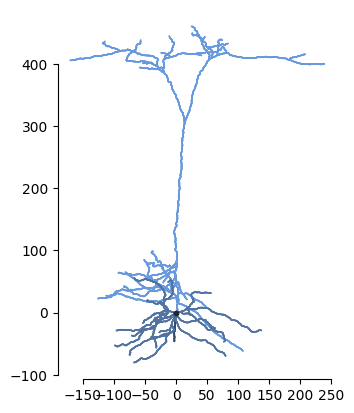

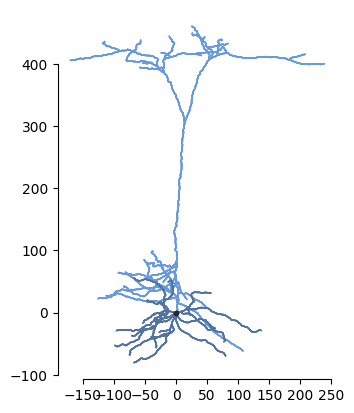

In [35]:
# show a cell before and after axon removal
cell_id = 485835016
path = Path('./skeletons/', str(cell_id))
path.mkdir(parents=True, exist_ok=True)

morphology = ctc.get_reconstruction(cell_id) 

# Rotate respecitve to pia.
morphology = rotate_cell(cell_id, morphology, df)

# Get soma coordinates.
soma = morphology.soma
soma_pos = np.array([soma['x'], soma['y'], soma['z']])
soma_id = soma['id']

# Process graph.
neighbors = {}
idx2node = {}
for i, item in enumerate(morphology.compartment_list):
    # Get node features.
    sec_type = [0, 0, 0, 0]
    sec_type[item['type'] - 1] = 1
    feat = tuple([item['x'], item['y'], item['z'], item['radius']]) + tuple(sec_type)
    idx2node[i] = feat
    
    # Get neighbors.
    neighbors[i] = set(item['children'])
    if item['parent'] != -1:
        neighbors[i].add(item['parent'])

features = np.array(list(idx2node.values()))

assert ~np.any(np.isnan(features))

# Normalize soma position to origin.
norm_features = features.copy()
norm_features[:, :3] = norm_features[:, :3] - soma_pos

# Test if graph is connected.
adj_matrix = neighbors_to_adjacency(neighbors, range(len(neighbors)))
G = nx.Graph(adj_matrix)
if nx.number_connected_components(G) > 1:
    adj_matrix, neighbors = connect_graph(adj_matrix, neighbors, features)
    
assert len(neighbors) == len(adj_matrix)

plot_neuron(neighbors, norm_features)

# Remove axons.
neighbors_removed, norm_features_removed, soma_id_removed = remove_axon(neighbors, norm_features, int(soma_id))

plot_neuron(neighbors_removed, norm_features_removed)

In [38]:
norm_features_removed.shape

(3846, 8)

In [42]:
norm_features.shape

(3893, 8)

In [43]:
norm_features[:, 5] 

array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
axon_mask = (features[:, 5] == 1)